# Catalog EDA

Doing some exploratory data analysis with my newly constructed catalog!

In [6]:
import xarray as xr
import pandas as pd
from pathlib import Path
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr

os.chdir('/global/homes/j/jbbutler/extreme_antarctic_ARs/scripts/')
from utils import display_catalog

In [7]:
# loading up the catalog
catalog = pd.read_hdf('~/extreme_antarctic_ARs/data/ar_database/dataframe_eps12_eps500_minpts5_reppts10/landfalling_storm_quantities_df.h5')
catalog = catalog[catalog.max_ocean_SLP_gradient >= 0]

In [8]:
saveable = catalog.loc[:, catalog.columns != 'data_array']
saveable['duration'] = saveable['duration']/pd.Timedelta(1, 'h')
saveable = saveable.loc[:, saveable.columns != 'start_time']
saveable = saveable.loc[:, saveable.columns != 'end_time']
saveable.to_csv('~/extreme_antarctic_ARs/data/ar_database/dataframe_eps12_eps500_minpts5_reppts10/landfalling_df_no_da.csv')

/tmp/ipykernel_582151/547727465.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  saveable['duration'] = saveable['duration']/pd.Timedelta(1, 'h')


In [5]:
subcat = catalog[['data_array', 'start_date', 'end_date', 'max_IWV_ais', 'max_ocean_SLP_gradient', 'max_T2M_anomaly_ais', 'cumulative_rainfall_ais', 'cumulative_snowfall_ais']]
subcat['cumulative_rainfall_ais'] = subcat['cumulative_rainfall_ais']/(10**13)
subcat['cumulative_snowfall_ais'] = subcat['cumulative_snowfall_ais']/(10**13)


/tmp/ipykernel_1923878/2715778439.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subcat['cumulative_rainfall_ais'] = subcat['cumulative_rainfall_ais']/(10**13)
/tmp/ipykernel_1923878/2715778439.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subcat['cumulative_snowfall_ais'] = subcat['cumulative_snowfall_ais']/(10**13)


In [6]:
subcat = subcat.rename(columns={'max_IWV_ais': 'IWV', 'max_ocean_SLP_gradient':'SLP_gradient', 'max_T2M_anomaly_ais':'T2m Anomaly', 'cumulative_rainfall_ais':'rainfall', 'cumulative_snowfall_ais':'snowfall'})

In [7]:
subcat.index.names = ['AR Number'] 

,data_array,start_date,end_date,IWV,SLP_gradient,T2m Anomaly,rainfall,snowfall
AR Number,,,,,,,,
1,,1980-01-02 00:00:00,1980-01-03 18:00:00,19.393877,4.899358,4.733398,0.000954,0.047941
3,,1980-01-06 18:00:00,1980-01-08 12:00:00,15.271224,5.984890,9.100540,0.014291,0.621764
11,,1980-01-11 12:00:00,1980-01-11 15:00:00,9.877011,2.867155,4.731720,0.001487,0.106674
13,,1980-01-13 00:00:00,1980-01-13 09:00:00,12.215693,4.138897,8.239502,0.001551,0.254120
14,,1980-01-14 12:00:00,1980-01-16 09:00:00,16.230389,3.984146,12.359955,0.034736,1.410684
15,,1980-01-17 06:00:00,1980-01-18 00:00:00,9.083025,4.265896,3.037811,0.000001,0.006909

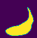
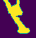

In [11]:
display_catalog(subcat[subcat.SLP_gradient >= 0], 6)

In [14]:
display_catalog(subcat.loc[[subcat.rainfall.idxmax()]][['start_date', 'end_date']])

,start_date,end_date
AR Number,,
8822,2022-02-05 12:00:00,2022-02-09 06:00:00


In [16]:
display_catalog(subcat.loc[[subcat.snowfall.idxmax()]][['start_date', 'end_date']])

,start_date,end_date
AR Number,,
8839,2022-03-13 15:00:00,2022-03-18 06:00:00


## Single Variable Plots

### Covariates

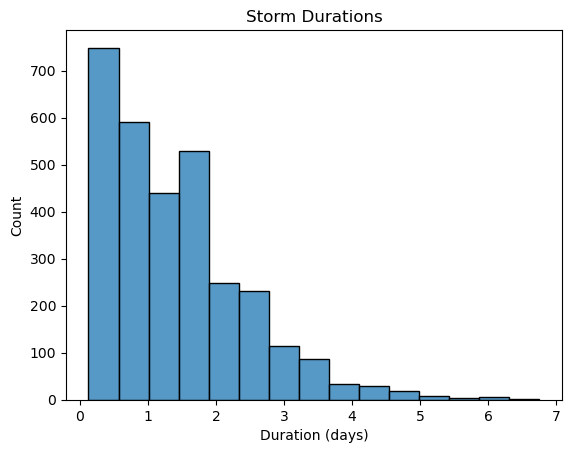

In [8]:
sns.histplot(data = catalog.duration/pd.Timedelta(1, 'd'), bins=15);
plt.title('Storm Durations');
plt.xlabel('Duration (days)');

**Fun Fact**: the longest AR in the catalog is one that's mentioned in *Climatology and surface impacts of atmospheric rivers on West Antarctica* by Maclennan et al. (2023). Although this paper calls it a family event with three ARs present.. did my catalog group them all together?

In [31]:
display_catalog(catalog.loc[[catalog.duration.idxmax()]])

,data_array,is_landfalling,max_area,mean_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,max_T2m_ais,avg_V10m_ais,max_V10m_ais,avg_IWV_ais,max_IWV_ais,avg_IWV,max_IWV,min_ocean_SLP,max_ocean_SLP_gradient,max_T2M_anomaly_ais,avg_vIVT_ais,max_vIVT_ais,avg_vIVT,max_vIVT,cumulative_rainfall_ais,cumulative_snowfall_ais,max_landfalling_v850hPa,avg_landfalling_v850hPa
AR Number,,,,,,,,,,,,,,,,,,,,,,,,,,,,
8621,,True,2730549.097429,1911614.547048,515210.898597,3477673.565531,6 days 18:00:00,2022-01-28 09:00:00,2022-02-04 00:00:00,-85.000000,275.990143,2.171551,16.053333,9.557386,19.773836,16.436357,47.749969,96275.578125,3.976208,20.211472,108.739159,380.246948,289.507700,1069.087402,451306814352.945374,26275174283795.941406,23.783997,17.244394052165983


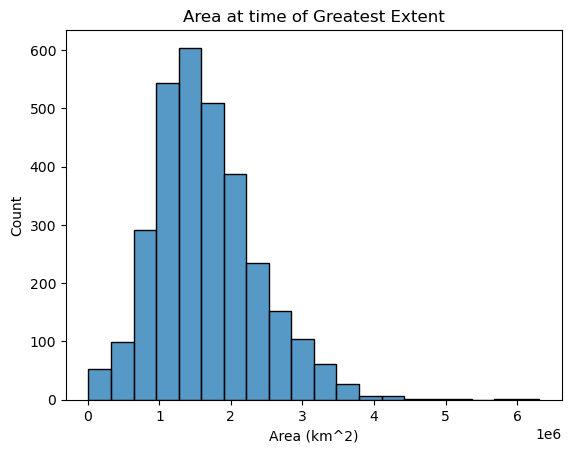

In [10]:
sns.histplot(data=catalog, x='max_area', bins=20);
plt.title('Area at time of Greatest Extent');
plt.xlabel('Area (km^2)');

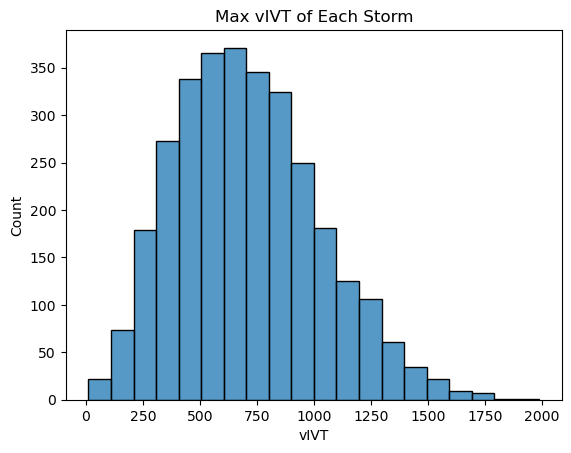

In [11]:
sns.histplot(data=catalog, x='max_vIVT', bins=20);
plt.title('Max vIVT of Each Storm');
plt.xlabel('vIVT');

,data_array,is_landfalling,max_area,mean_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,max_T2m_ais,avg_V10m_ais,max_V10m_ais,avg_IWV_ais,max_IWV_ais,avg_IWV,max_IWV,min_ocean_SLP,max_ocean_SLP_gradient,max_T2M_anomaly_ais,avg_vIVT_ais,max_vIVT_ais,avg_vIVT,max_vIVT,cumulative_rainfall_ais,cumulative_snowfall_ais,max_landfalling_v850hPa,avg_landfalling_v850hPa
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,
7005,,True,2891160.164788,2389805.571475,20700.923224,38814.231046,1 days 21:00:00,2015-02-03 03:00:00,2015-02-04 21:00:00,-69.500000,267.807129,-7.612618,0.000000,7.365378,14.359858,27.308932,51.842247,95969.234375,5.836656,2.336349,59.652332,146.783920,590.696551,1988.771851,2862304126.652631,2998968018924.224121,28.096794,16.975663409082596

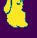

In [12]:
display_catalog(catalog.loc[[catalog.max_vIVT.idxmax()]])

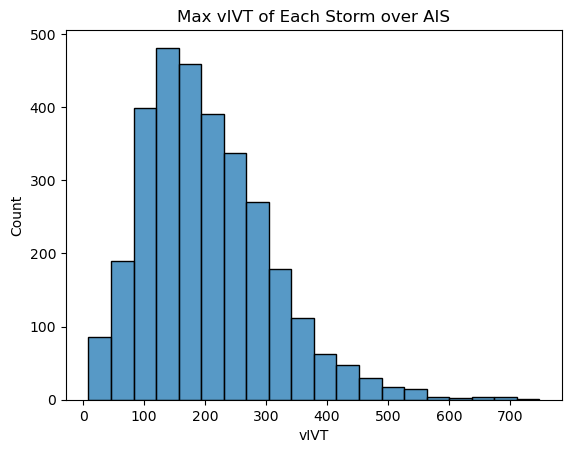

In [13]:
sns.histplot(data=catalog, x='max_vIVT_ais', bins=20);
plt.title('Max vIVT of Each Storm over AIS');
plt.xlabel('vIVT');

**Fun Fact**: the storm with the greatest landfalling vIVT was the same AR from Gorodetskaya.

In [14]:
display_catalog(catalog.loc[[catalog.max_vIVT_ais.idxmax()]])

,data_array,is_landfalling,max_area,mean_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,max_T2m_ais,avg_V10m_ais,max_V10m_ais,avg_IWV_ais,max_IWV_ais,avg_IWV,max_IWV,min_ocean_SLP,max_ocean_SLP_gradient,max_T2M_anomaly_ais,avg_vIVT_ais,max_vIVT_ais,avg_vIVT,max_vIVT,cumulative_rainfall_ais,cumulative_snowfall_ais,max_landfalling_v850hPa,avg_landfalling_v850hPa
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,
8628,,True,3877096.641947,2534757.261198,712098.379191,2759381.219366,3 days 21:00:00,2022-02-05 12:00:00,2022-02-09 06:00:00,-85.000000,279.027313,2.243421,17.935772,10.590826,27.609982,21.327350,45.593719,95253.109375,4.854247,20.089249,150.126116,748.183411,425.934919,1125.843506,3373056946182.324707,32726455731489.816406,29.558201,19.416923784909272


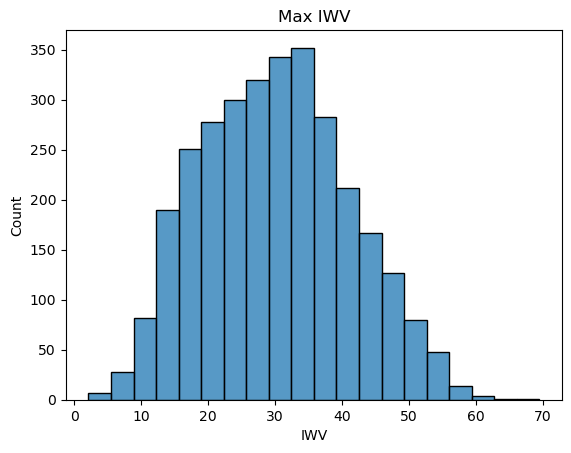

In [15]:
sns.histplot(data=catalog, x='max_IWV', bins=20);
plt.title('Max IWV');
plt.xlabel('IWV');

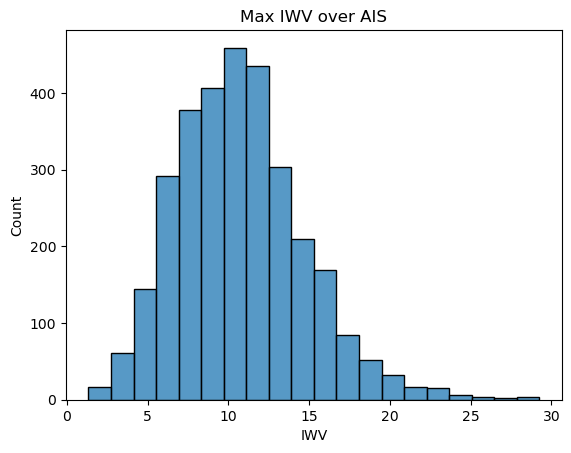

In [16]:
sns.histplot(data=catalog, x='max_IWV_ais', bins=20);
plt.title('Max IWV over AIS');
plt.xlabel('IWV');

In [18]:
display_catalog(catalog.loc[[catalog.max_IWV_ais.idxmax()]])

,data_array,is_landfalling,max_area,mean_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,max_T2m_ais,avg_V10m_ais,max_V10m_ais,avg_IWV_ais,max_IWV_ais,avg_IWV,max_IWV,min_ocean_SLP,max_ocean_SLP_gradient,max_T2M_anomaly_ais,avg_vIVT_ais,max_vIVT_ais,avg_vIVT,max_vIVT,cumulative_rainfall_ais,cumulative_snowfall_ais,max_landfalling_v850hPa,avg_landfalling_v850hPa
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,
4825,,True,3061358.166454,2066635.799071,501973.247743,1568666.399197,3 days 03:00:00,2005-02-08 12:00:00,2005-02-11 12:00:00,-85.000000,278.481018,2.071489,23.423197,9.604741,29.251392,22.385771,48.787693,96808.281250,4.235993,17.248505,140.250768,705.529114,403.804376,1005.653809,1922697885728.063232,30737799330482.054688,26.808243,18.268324379557725


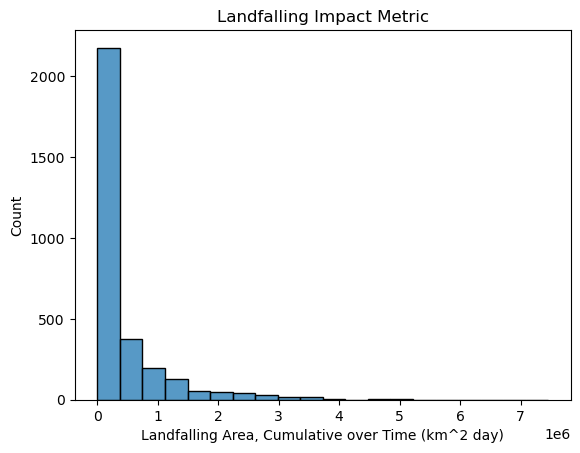

In [20]:
sns.histplot(data=catalog, x='cumulative_landfalling_area', bins=20);
plt.title('Landfalling Impact Metric');
plt.xlabel('Landfalling Area, Cumulative over Time (km^2 day)');

**Fun Fact**: AR with the highest value of this impact metric is the 2022 heatwave AR!

In [21]:
display_catalog(catalog.loc[[catalog.cumulative_landfalling_area.idxmax()]])

,data_array,is_landfalling,max_area,mean_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,max_T2m_ais,avg_V10m_ais,max_V10m_ais,avg_IWV_ais,max_IWV_ais,avg_IWV,max_IWV,min_ocean_SLP,max_ocean_SLP_gradient,max_T2M_anomaly_ais,avg_vIVT_ais,max_vIVT_ais,avg_vIVT,max_vIVT,cumulative_rainfall_ais,cumulative_snowfall_ais,max_landfalling_v850hPa,avg_landfalling_v850hPa
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,
8645,,True,6312220.950418,3405801.600498,1569910.210468,7457073.499721,4 days 18:00:00,2022-03-13 15:00:00,2022-03-18 06:00:00,-85.000000,278.642639,0.531637,15.266479,4.008752,23.074251,16.125991,45.662140,96281.687500,8.060711,40.972366,63.922712,482.539856,351.743068,1251.982056,679245650359.845337,72319870204593.062500,32.607830,21.10907646589442


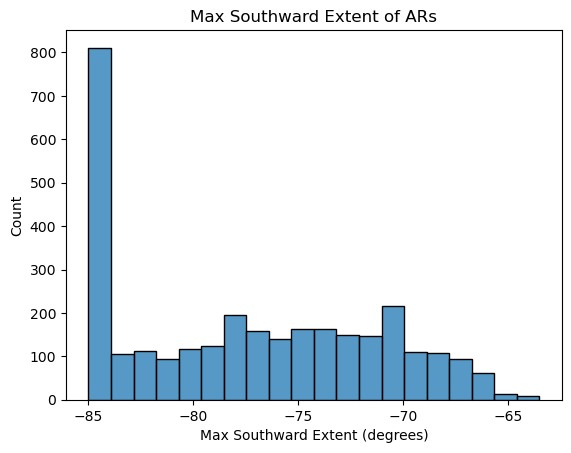

In [22]:
sns.histplot(data=catalog, x='max_south_extent', bins=20);
plt.title('Max Southward Extent of ARs');
plt.xlabel('Max Southward Extent (degrees)');

### Impact/Outcome Variables

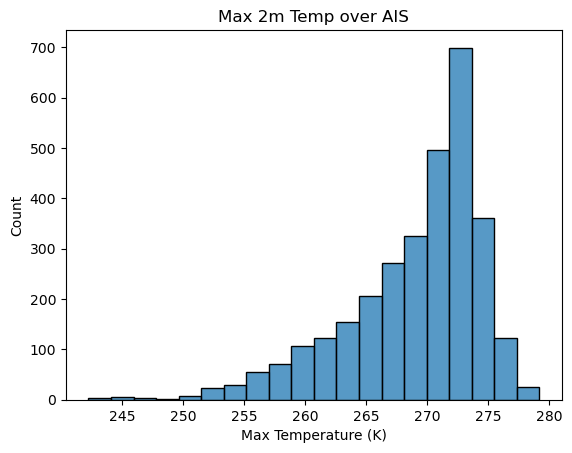

In [23]:
sns.histplot(data=catalog, x='max_T2m_ais', bins=20);
plt.title('Max 2m Temp over AIS');
plt.xlabel('Max Temperature (K)');

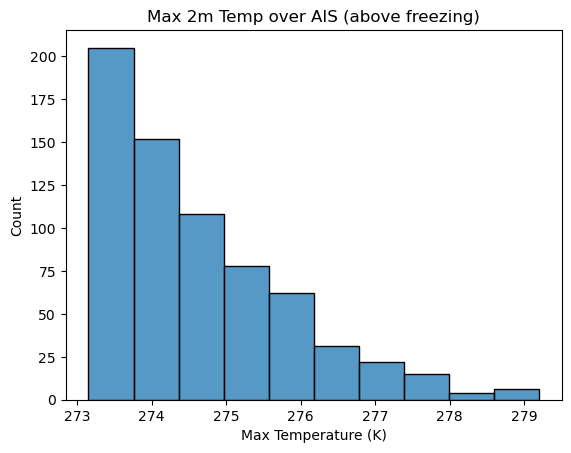

In [24]:
above_freezing = catalog.loc[catalog.max_T2m_ais >= 273.15]
sns.histplot(x=above_freezing.max_T2m_ais, bins=10);
plt.title('Max 2m Temp over AIS (above freezing)');
plt.xlabel('Max Temperature (K)');

**Fun Fact**: the storm with the highest landfalling temperature on the AIS was an AR that caused the Larsen A ice shelf collapse!

,data_array,is_landfalling,max_area,mean_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,max_T2m_ais,avg_V10m_ais,max_V10m_ais,avg_IWV_ais,max_IWV_ais,avg_IWV,max_IWV,min_ocean_SLP,max_ocean_SLP_gradient,max_T2M_anomaly_ais,avg_vIVT_ais,max_vIVT_ais,avg_vIVT,max_vIVT,cumulative_rainfall_ais,cumulative_snowfall_ais,max_landfalling_v850hPa,avg_landfalling_v850hPa
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2867,,True,2262846.280307,2112468.956708,105471.757808,118655.727534,1 days 03:00:00,1995-01-24 00:00:00,1995-01-25 00:00:00,-76.500000,279.203552,6.461016,19.237509,14.506771,25.030884,23.756501,39.180656,94993.968750,6.684744,9.236847,263.376383,626.006409,494.445933,982.367371,1037725997306.208862,5195927241157.639648,35.177967,19.078717422054

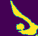

In [27]:
display_catalog(catalog.loc[[catalog.max_T2m_ais.idxmax()]])

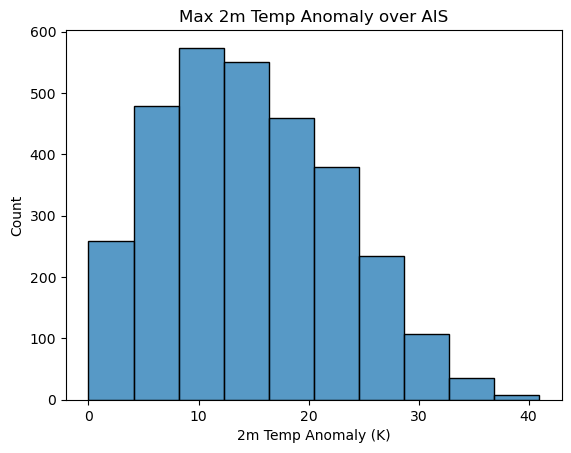

In [28]:
sns.histplot(data=catalog, x='max_T2M_anomaly_ais', bins=10);
plt.title('Max 2m Temp Anomaly over AIS');
plt.xlabel('2m Temp Anomaly (K)');

**Fun Fact**: the storm with the highest max temp anomaly over the ice sheet was the Antarctic AR!

In [29]:
display_catalog(catalog.loc[[catalog.max_T2M_anomaly_ais.idxmax()]])

,data_array,is_landfalling,max_area,mean_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,max_T2m_ais,avg_V10m_ais,max_V10m_ais,avg_IWV_ais,max_IWV_ais,avg_IWV,max_IWV,min_ocean_SLP,max_ocean_SLP_gradient,max_T2M_anomaly_ais,avg_vIVT_ais,max_vIVT_ais,avg_vIVT,max_vIVT,cumulative_rainfall_ais,cumulative_snowfall_ais,max_landfalling_v850hPa,avg_landfalling_v850hPa
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,
8645,,True,6312220.950418,3405801.600498,1569910.210468,7457073.499721,4 days 18:00:00,2022-03-13 15:00:00,2022-03-18 06:00:00,-85.000000,278.642639,0.531637,15.266479,4.008752,23.074251,16.125991,45.662140,96281.687500,8.060711,40.972366,63.922712,482.539856,351.743068,1251.982056,679245650359.845337,72319870204593.062500,32.607830,21.10907646589442


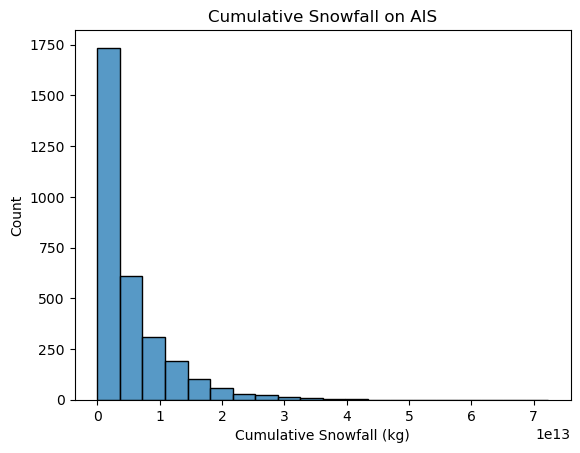

In [30]:
sns.histplot(data=catalog, x='cumulative_snowfall_ais', bins=20);
plt.title('Cumulative Snowfall on AIS');
plt.xlabel('Cumulative Snowfall (kg)');

**Fun Fact**: the storm that dumped the most snowfall on record of any AR in the catalog was the one that caused the 2022 heat wave.

In [31]:
display_catalog(catalog.loc[[catalog.cumulative_snowfall_ais.idxmax()]])

,data_array,is_landfalling,max_area,mean_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,max_T2m_ais,avg_V10m_ais,max_V10m_ais,avg_IWV_ais,max_IWV_ais,avg_IWV,max_IWV,min_ocean_SLP,max_ocean_SLP_gradient,max_T2M_anomaly_ais,avg_vIVT_ais,max_vIVT_ais,avg_vIVT,max_vIVT,cumulative_rainfall_ais,cumulative_snowfall_ais,max_landfalling_v850hPa,avg_landfalling_v850hPa
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,
8645,,True,6312220.950418,3405801.600498,1569910.210468,7457073.499721,4 days 18:00:00,2022-03-13 15:00:00,2022-03-18 06:00:00,-85.000000,278.642639,0.531637,15.266479,4.008752,23.074251,16.125991,45.662140,96281.687500,8.060711,40.972366,63.922712,482.539856,351.743068,1251.982056,679245650359.845337,72319870204593.062500,32.607830,21.10907646589442


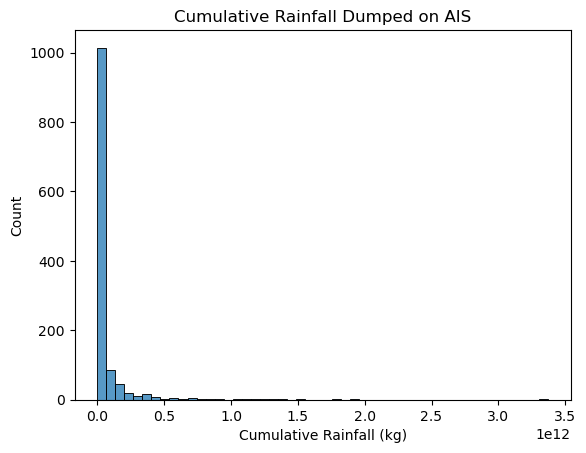

In [32]:
sns.histplot(data=catalog.loc[catalog.cumulative_rainfall_ais > 0], x='cumulative_rainfall_ais', bins=50);
plt.title('Cumulative Rainfall Dumped on AIS');
plt.xlabel('Cumulative Rainfall (kg)');

**Fun Fact**: storm that dumped the most rain on record (almost twice the amount of rain as the next biggest storm) is an AR from February 2022, studied in Gorodestskaya et al. (2023) (*Record-high Antarctic Peninsula temperatures and surface melt in February 2022: a compound event with an intense atmospheric river*)

In [33]:
display_catalog(catalog.loc[[catalog.cumulative_rainfall_ais.idxmax()]])

,data_array,is_landfalling,max_area,mean_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,max_T2m_ais,avg_V10m_ais,max_V10m_ais,avg_IWV_ais,max_IWV_ais,avg_IWV,max_IWV,min_ocean_SLP,max_ocean_SLP_gradient,max_T2M_anomaly_ais,avg_vIVT_ais,max_vIVT_ais,avg_vIVT,max_vIVT,cumulative_rainfall_ais,cumulative_snowfall_ais,max_landfalling_v850hPa,avg_landfalling_v850hPa
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,
8628,,True,3877096.641947,2534757.261198,712098.379191,2759381.219366,3 days 21:00:00,2022-02-05 12:00:00,2022-02-09 06:00:00,-85.000000,279.027313,2.243421,17.935772,10.590826,27.609982,21.327350,45.593719,95253.109375,4.854247,20.089249,150.126116,748.183411,425.934919,1125.843506,3373056946182.324707,32726455731489.816406,29.558201,19.416923784909272


Among all ARs, every AR dumped some snow. Among those ARs, about 38% of them also dumped rain.

In [34]:
data_crosstab = pd.crosstab(catalog.cumulative_rainfall_ais > 0, 
                            catalog.cumulative_snowfall_ais > 0,  
                               margins = False, normalize='all') 
data_crosstab

cumulative_snowfall_ais,True
cumulative_rainfall_ais,
False,0.60136
True,0.39864


In [35]:
display_catalog(catalog.loc[[catalog.cumulative_rainfall_ais.idxmax()]])

,data_array,is_landfalling,max_area,mean_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,max_T2m_ais,avg_V10m_ais,max_V10m_ais,avg_IWV_ais,max_IWV_ais,avg_IWV,max_IWV,min_ocean_SLP,max_ocean_SLP_gradient,max_T2M_anomaly_ais,avg_vIVT_ais,max_vIVT_ais,avg_vIVT,max_vIVT,cumulative_rainfall_ais,cumulative_snowfall_ais,max_landfalling_v850hPa,avg_landfalling_v850hPa
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,
8628,,True,3877096.641947,2534757.261198,712098.379191,2759381.219366,3 days 21:00:00,2022-02-05 12:00:00,2022-02-09 06:00:00,-85.000000,279.027313,2.243421,17.935772,10.590826,27.609982,21.327350,45.593719,95253.109375,4.854247,20.089249,150.126116,748.183411,425.934919,1125.843506,3373056946182.324707,32726455731489.816406,29.558201,19.416923784909272


## Multi-variable Plots

In [36]:
catalog.columns

Index(['data_array', 'is_landfalling', 'max_area', 'mean_area',
       'mean_landfalling_area', 'cumulative_landfalling_area', 'duration',
       'start_date', 'end_date', 'max_south_extent', 'max_T2m_ais',
       'avg_V10m_ais', 'max_V10m_ais', 'avg_IWV_ais', 'max_IWV_ais', 'avg_IWV',
       'max_IWV', 'min_ocean_SLP', 'max_ocean_SLP_gradient',
       'max_T2M_anomaly_ais', 'avg_vIVT_ais', 'max_vIVT_ais', 'avg_vIVT',
       'max_vIVT', 'cumulative_rainfall_ais', 'cumulative_snowfall_ais',
       'max_landfalling_v850hPa', 'avg_landfalling_v850hPa'],
      dtype='object')

<Axes: xlabel='max_landfalling_v850hPa', ylabel='cumulative_snowfall_ais'>

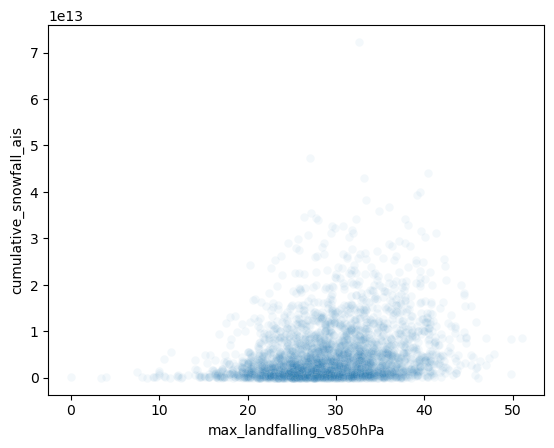

In [41]:
sns.scatterplot(data=catalog, x='max_landfalling_v850hPa', y='cumulative_snowfall_ais', alpha=0.05)

<Axes: xlabel='max_ocean_SLP_gradient', ylabel='cumulative_snowfall_ais'>

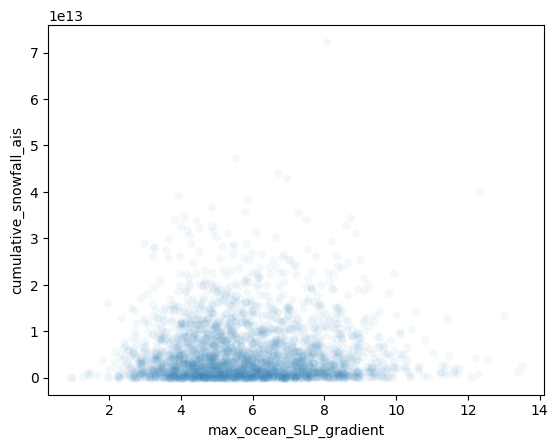

In [40]:
sns.scatterplot(data=catalog, x='max_ocean_SLP_gradient', y='cumulative_snowfall_ais', alpha=0.05)

<Axes: xlabel='max_ocean_SLP_gradient', ylabel='max_T2M_anomaly_ais'>

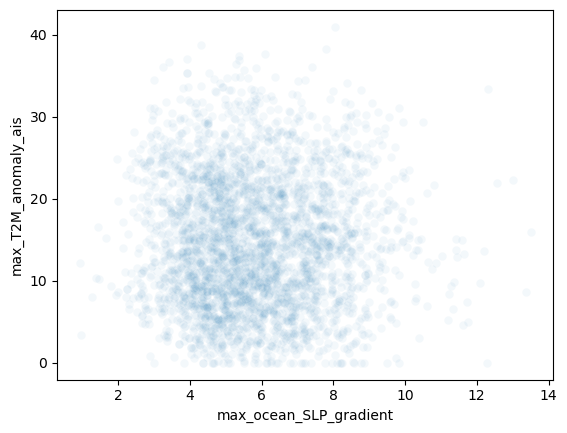

In [42]:
sns.scatterplot(data=catalog, x='max_ocean_SLP_gradient', y='max_T2M_anomaly_ais', alpha=0.05)

<Axes: xlabel='max_ocean_SLP_gradient', ylabel='max_T2m_ais'>

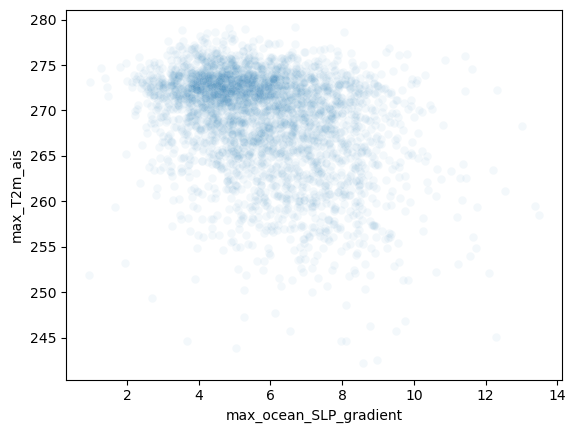

In [43]:
sns.scatterplot(data=catalog, x='max_ocean_SLP_gradient', y='max_T2m_ais', alpha=0.05)

<Axes: xlabel='max_landfalling_v850hPa', ylabel='max_T2m_ais'>

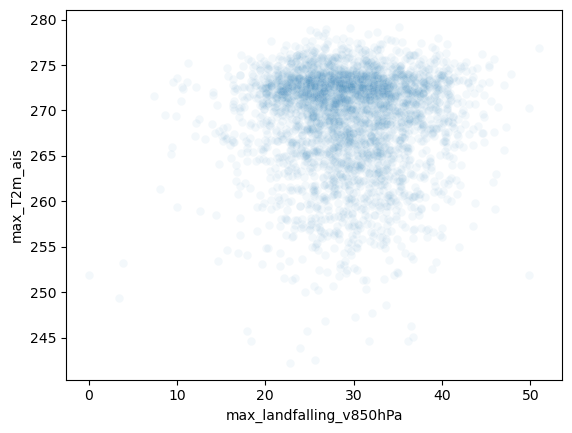

In [44]:
sns.scatterplot(data=catalog, x='max_landfalling_v850hPa', y='max_T2m_ais', alpha=0.05)

<Axes: xlabel='max_landfalling_v850hPa', ylabel='max_T2M_anomaly_ais'>

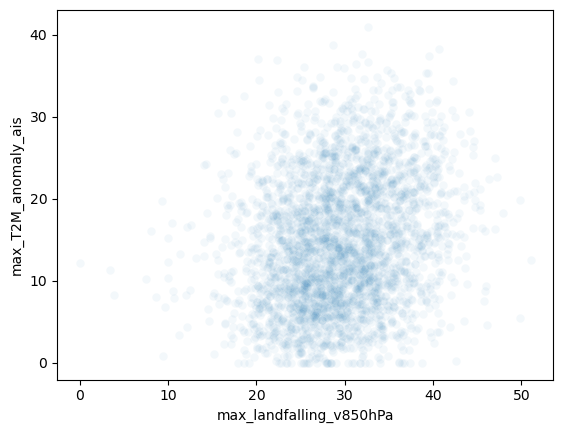

In [46]:
sns.scatterplot(data=catalog, x='max_landfalling_v850hPa', y='max_T2M_anomaly_ais', alpha=0.05)

In [1]:
sns.scatterplot(data=catalog, x='max_ocean_SLP_gradient', y='max_vIVT', alpha=0.05)

NameError: name 'sns' is not defined

<Axes: xlabel='max_T2m_ais', ylabel='cumulative_rainfall_ais'>

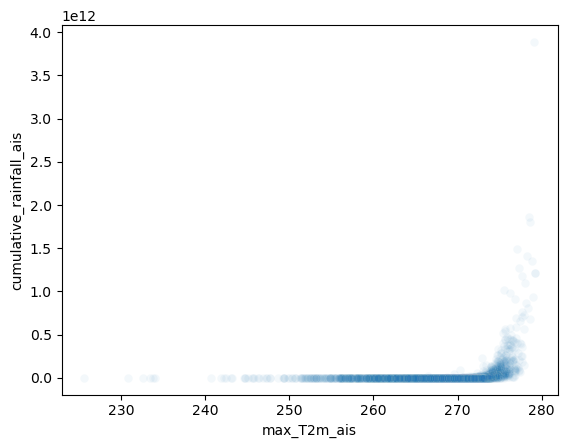

In [46]:
sns.scatterplot(data=catalog, x='max_T2m_ais', y='cumulative_rainfall_ais', alpha=0.05)

<Axes: xlabel='avg_IWV_ais', ylabel='max_T2M_anomaly_ais'>

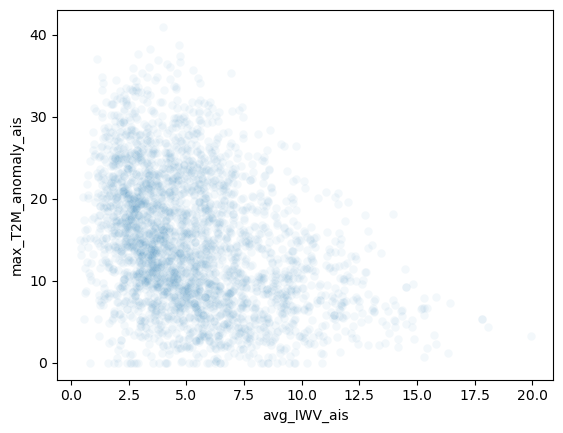

In [39]:
sns.scatterplot(data=catalog, x='avg_IWV_ais', y='max_T2M_anomaly_ais', alpha=0.05)

<Axes: xlabel='avg_V10m', ylabel='max_T2M_anomaly_ais'>

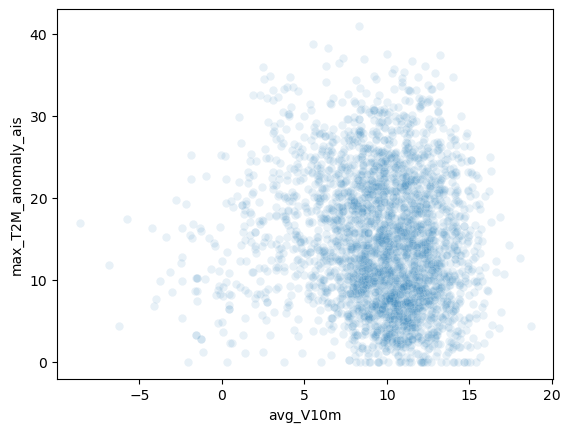

In [35]:
sns.scatterplot(data=catalog, x='avg_V10m', y='max_T2M_anomaly_ais', alpha=0.1)

<Axes: xlabel='mean_landfalling_area', ylabel='max_T2M_anomaly_ais'>

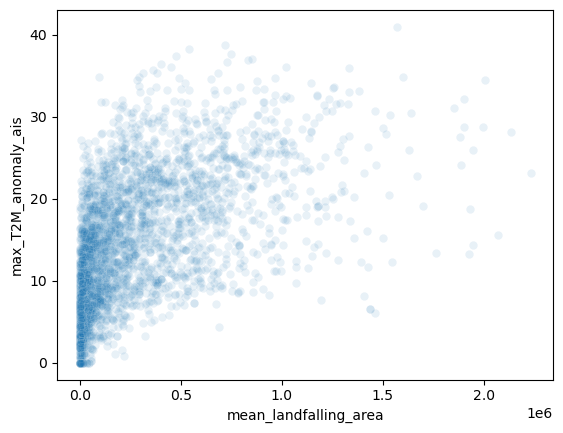

In [41]:
sns.scatterplot(data=catalog, x='mean_landfalling_area', y='max_T2M_anomaly_ais', alpha=0.1)

<Axes: xlabel='cumulative_landfalling_area', ylabel='max_T2M_anomaly_ais'>

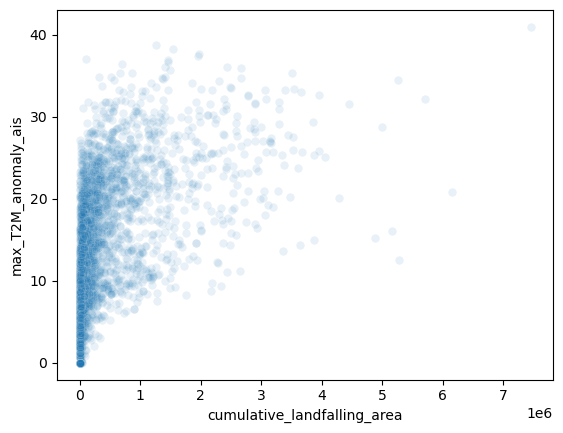

In [42]:
sns.scatterplot(data=catalog, x='cumulative_landfalling_area', y='max_T2M_anomaly_ais', alpha=0.1)

<Axes: xlabel='cumulative_landfalling_area', ylabel='cumulative_snowfall_ais'>

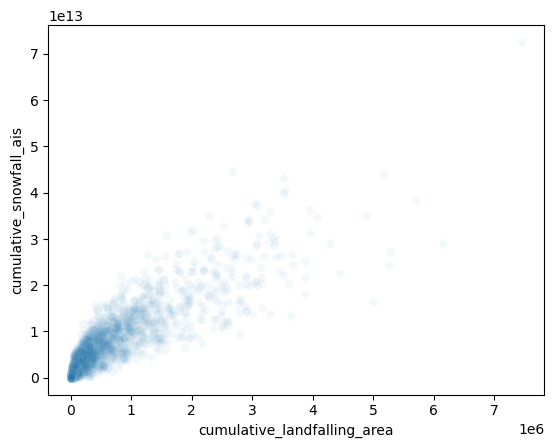

In [47]:
sns.scatterplot(data=catalog, x='cumulative_landfalling_area', y='cumulative_snowfall_ais', alpha=0.05)

<Axes: xlabel='duration', ylabel='cumulative_snowfall_ais'>

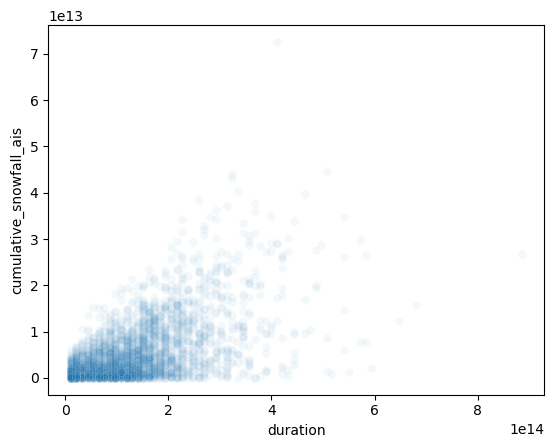

In [50]:
sns.scatterplot(data=catalog, x='duration', y='cumulative_snowfall_ais', alpha=0.05)

<Axes: xlabel='landfalling_SLP', ylabel='cumulative_snowfall_ais'>

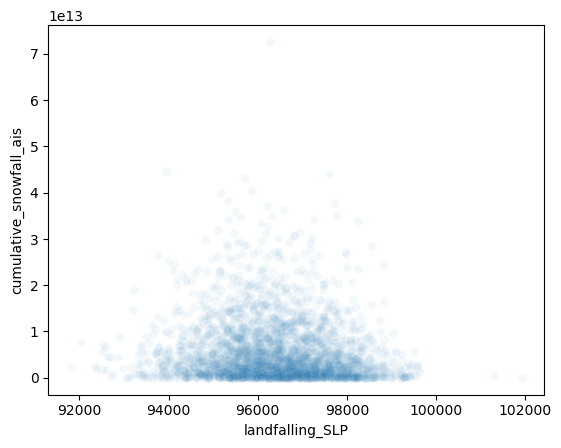

In [52]:
sns.scatterplot(data=catalog[catalog.landfalling_SLP < 1000000], x='landfalling_SLP', y='cumulative_snowfall_ais', alpha=0.05)

<Axes: xlabel='landfalling_SLP', ylabel='cumulative_rainfall_ais'>

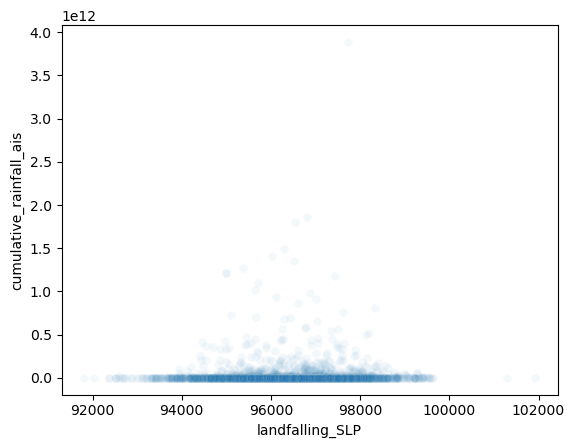

In [53]:
sns.scatterplot(data=catalog[catalog.landfalling_SLP < 1000000], x='landfalling_SLP', y='cumulative_rainfall_ais', alpha=0.05)

<Axes: xlabel='avg_V10m', ylabel='cumulative_snowfall_ais'>

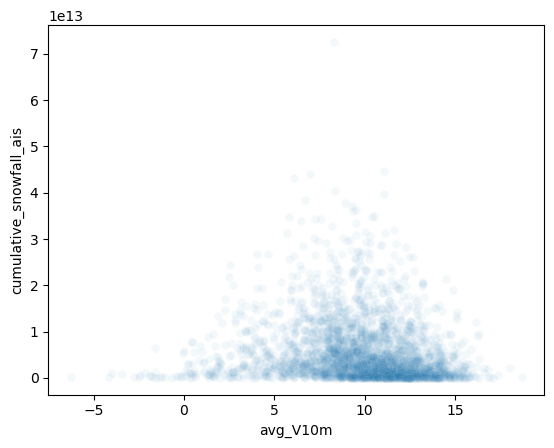

In [55]:
sns.scatterplot(data=catalog, x='avg_V10m', y='cumulative_snowfall_ais', alpha=0.05)

<Axes: xlabel='avg_V10m', ylabel='cumulative_snowfall_ais'>

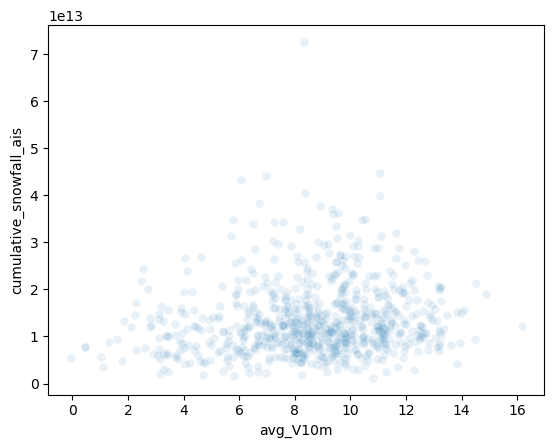

In [113]:
sns.scatterplot(data=high_impact, x='avg_V10m', y='cumulative_snowfall_ais', alpha=0.1)

In [276]:
vals_ais = catalog[['max_T2M_anomaly_ais', 'cumulative_snowfall_ais', 'cumulative_rainfall_ais', 'max_T2m_ais', 'cumulative_landfalling_area', 'mean_landfalling_area', 'duration', 'landfalling_SLP', 'max_V10m_ais', 'max_IWV_ais', 'max_vIVT_ais', 'max_south_extent']]

In [277]:
vals_ais.corr()[['max_T2M_anomaly_ais', 'cumulative_snowfall_ais', 'cumulative_rainfall_ais', 'max_T2m_ais']]

,max_T2M_anomaly_ais,cumulative_snowfall_ais,cumulative_rainfall_ais,max_T2m_ais
max_T2M_anomaly_ais,1.000000,0.552653,0.017878,0.215000
cumulative_snowfall_ais,0.552653,1.000000,0.250135,0.405331
cumulative_rainfall_ais,0.017878,0.250135,1.000000,0.240322
max_T2m_ais,0.215000,0.405331,0.240322,1.000000
cumulative_landfalling_area,0.501266,0.877742,0.166068,0.303307
mean_landfalling_area,0.538818,0.613771,0.075049,0.248723
duration,0.286098,0.567072,0.157352,0.275517
landfalling_SLP,-0.042744,-0.118309,-0.028675,-0.291694
max_V10m_ais,0.605238,0.527221,0.134944,0.450935
max_IWV_ais,0.079915,0.457502,0.418933,0.775768


Findings:

+ Modestly positive associations between the AIS 2m-Temp Anomaly and spatial extent of storm (to a lesser extent, duration), the max 10m poleward wind speed. Modest positive association with vIVT, but this seems to be due to associations with V rather than IWV, which has a seemingly negligible correlation. Strong negative association between max southward extent and 2m temperature anomaly (AKA, storms that penetrate further south have higher temp anomalies). No real association between the landfalling SLP and the temperature anomalies.

+ Strong positive association between snowfall and notions of duration and extent over the ice sheet. Somewhat negative association between landfalling SLP and snowfall? At least higher than 2m temp anomalies. Modest positive associations between 10m windspeed and IWV, producing a modest association with vIVT. Also association between how far it penetrates downward into continent and the cumulative snowfall.

+ Less strong associations between absolute 2m-temp and notions of duration and extent over ice sheet. More negative association with SLP. MUCH stronger association with IWV than the anomaly had: is this picking up on storms making landfall near the coast/the AP storms? Much less association of how far the storm penetrates southward on the continent with absolute temp.



In [18]:
catalog.columns

Index(['data_array', 'is_landfalling', 'max_area', 'mean_area',
       'mean_landfalling_area', 'cumulative_landfalling_area', 'duration',
       'start_date', 'end_date', 'max_south_extent', 'max_T2m_ais',
       'avg_IWV_ais', 'max_IWV_ais', 'max_ocean_SLP_gradient',
       'max_T2M_anomaly_ais', 'avg_vIVT_ais', 'max_vIVT_ais', 'avg_vIVT',
       'max_vIVT', 'cumulative_rainfall_ais', 'cumulative_snowfall_ais',
       'max_landfalling_v850hPa', 'avg_landfalling_v850hPa'],
      dtype='object')

In [12]:
catalog['cumulative_snowfall_ais'] = catalog['cumulative_snowfall_ais']/10**13
catalog['cumulative_rainfall_ais'] = catalog['cumulative_rainfall_ais']/10**13

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=5)
fig.set_size_inches(18, 6)

impact1 = "max_T2M_anomaly_ais"
impact2 = "cumulative_snowfall_ais"

#fig.suptitle('Pairwise Relationships between Impacts and Covariates', fontsize=22)

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact1, fill=True, ax=axs[0,0])
axs[0,0].set_xlabel('')
axs[0,0].set_ylabel('T Anomaly ($^{\\circ}$C)', fontsize=18)
axs[0,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_ais, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_ais", y=impact1, fill=True, ax=axs[0,1])
axs[0,1].set_xlabel('')
axs[0,1].set_ylabel('')
axs[0,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact1, fill=True, ax=axs[0,2])
axs[0,2].set_xlabel('')
axs[0,2].set_ylabel('')
axs[0,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[0,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact1, fill=True, ax=axs[0,3])
axs[0,3].set_xlabel('')
axs[0,3].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact1, fill=True, ax=axs[0,4])
axs[0,4].set_xlabel('')
axs[0,4].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact2, fill=True, ax=axs[1,0])
axs[1,0].set_xlabel('V850 hPa (m/s)', fontsize=18)
axs[1,0].set_ylabel('Snow (Gt)', fontsize=18)
axs[1,0].set_ylim(-0.2, 3)
axs[1,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_ais, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_ais", y=impact2, fill=True, ax=axs[1,1])
axs[1,1].set_xlabel('IWV (kg/m$^{2}$)', fontsize=18)
axs[1,1].set_ylabel('')
axs[1,1].set_ylim(-0.2, 3)
axs[1,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact2, fill=True, ax=axs[1,2])
axs[1,2].set_xlabel('CLA (km$^{2} $ day)', fontsize=18)
axs[1,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[1,2].set_ylabel('')
axs[1,2].set_ylim(-0.2, 3)
axs[1,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact2, fill=True, ax=axs[1,3])
axs[1,3].set_xlabel('South Extent ($^{\\circ}$ Lat.)', fontsize=18)
axs[1,3].set_ylabel('')
axs[1,3].set_ylim(-0.2, 3)
axs[1,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact2, fill=True, ax=axs[1,4])
axs[1,4].set_xlabel('SLP Gradient (hPa/km)', fontsize=18)
axs[1,4].set_ylabel('')
axs[1,4].set_ylim(-0.2, 3)
axs[1,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);
plt.savefig('/global/homes/j/jbbutler/extreme_antarctic_ARs/plots/aarg_25_plots/pairwise_relationships.png', dpi=300)